In [1]:
# Async send-on delta modulation

In [2]:
import h5py as h5
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

ORIGINAL_DATASET_DIR = "../ATMEGA-AES-ASCAD_databases"
ORIGINAL_H5 = f"{ORIGINAL_DATASET_DIR}/ASCAD.h5"
MODULATED_H5 = "../modulated_dataset/ascad_modulated.h5"

if not os.path.exists(ORIGINAL_H5):
    print(f"Error: Directory '{ORIGINAL_DATASET_DIR}' or file 'ASCAD.h5' not found.")
    print("Please create the directory and add the original 'ASCAD.h5' file to execute this code.")
    sys.exit(1)

In [3]:
bd = h5.File(ORIGINAL_H5, "r")

print(list(bd.keys()))

print("Keys in Profiling_traces and Attack_traces:\n")

print(list(bd["Profiling_traces"].keys()))
print(list(bd["Attack_traces"].keys()))

print("\nProfiling_traces shapes:")

print(list(bd["Profiling_traces"]["traces"].shape))
print(list(bd["Profiling_traces"]["labels"].shape))
print(list(bd["Profiling_traces"]["metadata"].shape))

print("\nAttack_traces shapes:")

print(list(bd["Attack_traces"]["traces"].shape))
print(list(bd["Attack_traces"]["labels"].shape))
print(list(bd["Attack_traces"]["metadata"].shape))

['Attack_traces', 'Profiling_traces']
Keys in Profiling_traces and Attack_traces:

['labels', 'metadata', 'traces']
['labels', 'metadata', 'traces']

Profiling_traces shapes:
[50000, 700]
[50000]
[50000]

Attack_traces shapes:
[10000, 700]
[10000]
[10000]


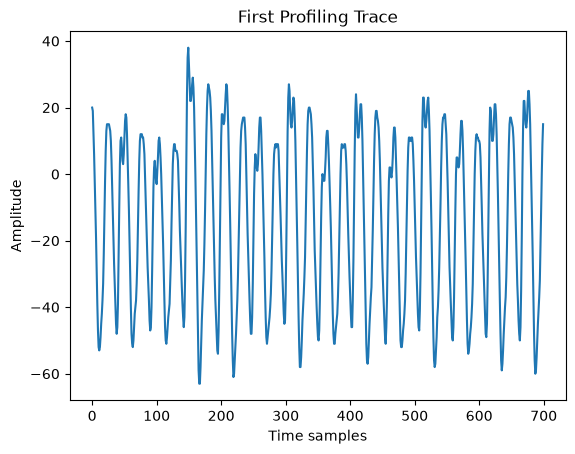

In [4]:
plt.plot(bd["Profiling_traces"]["traces"][0])
plt.title("First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Amplitude")
plt.show() 

In [5]:
amostras = bd["Profiling_traces"]["traces"][:50000]

# int8 to int32 to avoid overflow
amostras_int32 = np.array(amostras, dtype=np.int32)

# derivative across time samples
derivadas = np.diff(amostras_int32, axis=1)

# convert all to absolute value
derivadas_absolutas = np.abs(derivadas)

# mean across all 10,000 traces and round to integer threshold
threshold_ideal = int(np.round(np.mean(derivadas_absolutas)))

print(f"ideal threshold: {threshold_ideal}")

ideal threshold: 6


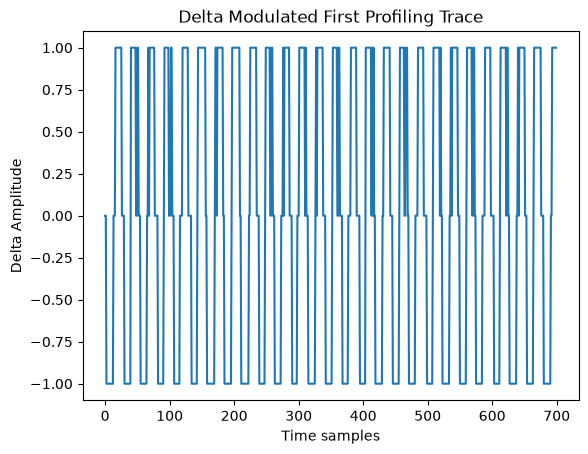

In [6]:
import delta_mod

threshold = threshold_ideal
delta_traces = [list(delta_mod.delta_modulation(trace, threshold)) for trace in bd["Profiling_traces"]["traces"]]

plt.plot(delta_traces[0])
plt.title("Delta Modulated First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Delta Amplitude")
plt.show()

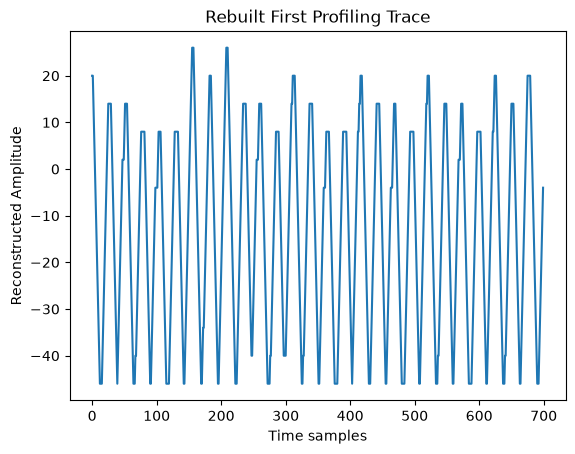

In [7]:
rebuilt_traces = [list(delta_mod.rebuild_trace(delta_trace, bd["Profiling_traces"]["traces"][i][0], threshold)) for i, delta_trace in enumerate(delta_traces)]

plt.plot(rebuilt_traces[0])
plt.title("Rebuilt First Profiling Trace")
plt.xlabel("Time samples")
plt.ylabel("Reconstructed Amplitude")
plt.show()

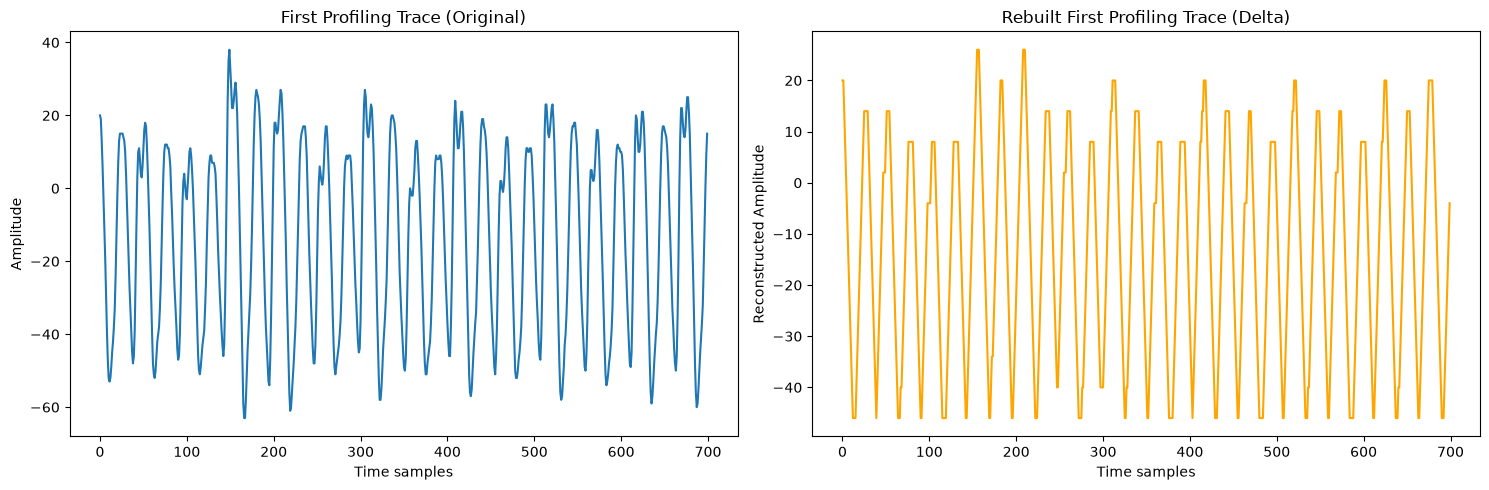

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(bd["Profiling_traces"]["traces"][0])
ax1.set_title("First Profiling Trace (Original)")
ax1.set_xlabel("Time samples")
ax1.set_ylabel("Amplitude")

ax2.plot(rebuilt_traces[0], color='orange')
ax2.set_title("Rebuilt First Profiling Trace (Delta)")
ax2.set_xlabel("Time samples")
ax2.set_ylabel("Reconstructed Amplitude")

plt.tight_layout()
plt.show()

## Post Delta Mod H5 db

In [9]:
# Ensure the modulated file exists before trying to read it
if not os.path.exists(MODULATED_H5):
    print(f"Error: Modulated dataset not found at {MODULATED_H5}.")
    print("Make sure you run the modulation script first.")
    sys.exit(1)

bd_mod = h5.File(MODULATED_H5, "r")

print(list(bd_mod.keys()))

print("Keys in Profiling_traces and Attack_traces:\n")

print(list(bd_mod["Profiling_traces"].keys()))
print(list(bd_mod["Attack_traces"].keys()))

print("\nProfiling_traces shapes:")

print(list(bd_mod["Profiling_traces"]["traces"].shape))
print(list(bd_mod["Profiling_traces"]["labels"].shape))
print(list(bd_mod["Profiling_traces"]["metadata"].shape))

print("\nAttack_traces shapes:")

print(list(bd_mod["Attack_traces"]["traces"].shape))
print(list(bd_mod["Attack_traces"]["labels"].shape))
print(list(bd_mod["Attack_traces"]["metadata"].shape))

['Attack_traces', 'Profiling_traces']
Keys in Profiling_traces and Attack_traces:

['labels', 'labels_hw_byte0', 'metadata', 'traces']
['labels', 'labels_hw_byte0', 'metadata', 'traces']

Profiling_traces shapes:
[50000, 700]
[50000]
[50000]

Attack_traces shapes:
[10000, 700]
[10000]
[10000]


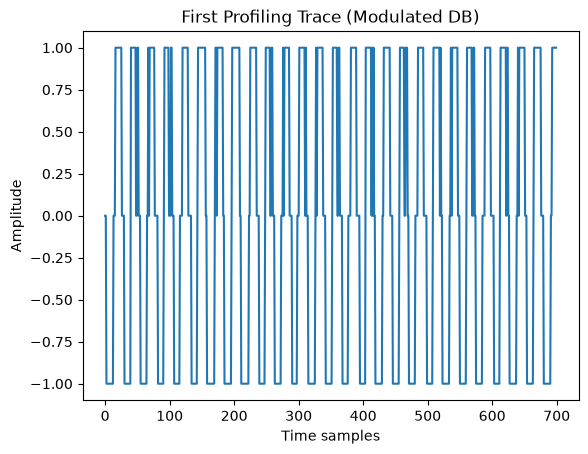

In [10]:
plt.plot(bd_mod["Profiling_traces"]["traces"][0])
plt.title("First Profiling Trace (Modulated DB)")
plt.xlabel("Time samples")
plt.ylabel("Amplitude")
plt.show()

In [11]:
metadata = bd_mod["Profiling_traces"]["metadata"]
print("metadata type:", type(metadata))
print("metadata shape:", metadata.shape)
print("metadata dtype:", metadata.dtype)
print("metadata dtype names:", metadata.dtype.names)
print("\nFirst rows:")
print(metadata[:3])
#('plaintext', 'ciphertext', 'key', 'masks', 'desync')

metadata_plaintext = metadata["plaintext"]
metadata_ciphertext = metadata["ciphertext"]
metadata_key = metadata["key"]
metadata_masks = metadata["masks"]
metadata_desync = metadata["desync"]

metadata type: <class 'h5py._hl.dataset.Dataset'>
metadata shape: (50000,)
metadata dtype: [('plaintext', 'u1', (16,)), ('ciphertext', 'u1', (16,)), ('key', 'u1', (16,)), ('masks', 'u1', (16,)), ('desync', '<u4', (1,))]
metadata dtype names: ('plaintext', 'ciphertext', 'key', 'masks', 'desync')

First rows:
[([  6,  65, 195,  66,  25, 182, 248,  19, 159, 132,  97,   6,  46, 137,  42,  16], [ 95,  75, 255, 146, 229,  35,  24,  50,  16, 107, 238,  33,  93,  56, 106, 178], [ 77, 251, 224, 242, 114,  33, 254,  16, 167, 141,  74, 220, 142,  73,   4, 105], [  7,  84,  71, 171, 129, 171,  90, 193, 236, 131,  21, 112, 185,  95, 212,  55], [0])
 ([ 64,  84, 174, 122,  92, 107, 179,   4, 192,  55,  90, 128, 132,  74, 139,  27], [ 23, 248, 254,  14,  91, 201,   8, 132,  57, 212, 123,  91,  91, 233, 227,  72], [ 77, 251, 224, 242, 114,  33, 254,  16, 167, 141,  74, 220, 142,  73,   4, 105], [192, 166,  45,  89, 164,  22, 209, 144,   3, 192, 239, 152, 122,   7, 185,  67], [0])
 ([202, 207, 195,  33

## Hamming Weights

In [13]:
from delta_mod import calculate_hw_labels
import h5py as h5

if 'bd_mod' in locals() and isinstance(bd_mod, h5.File):
    bd_mod.close()

with h5.File(MODULATED_H5, "r+") as db:
    for group in ["Profiling_traces", "Attack_traces"]:
        metadata = db[group]["metadata"]
        
        pt_byte0 = metadata["plaintext"][:, 0]
        key_byte0 = metadata["key"][:, 0]
        
        hw_labels = calculate_hw_labels(pt_byte0, key_byte0)
        
        dataset_name = "labels_hw_byte0"
        
        if dataset_name in db[group]:
            del db[group][dataset_name]
            
        db[group].create_dataset(dataset_name, data=hw_labels, dtype=np.uint8)
        
        print(f"[{group}] {len(hw_labels)} calculated and saved to '{group}/{dataset_name}'")

[Profiling_traces] 50000 calculated and saved to 'Profiling_traces/labels_hw_byte0'
[Attack_traces] 10000 calculated and saved to 'Attack_traces/labels_hw_byte0'


In [14]:
bd_hw = h5.File(MODULATED_H5, "r")

print(list(bd_hw.keys()))

print("Keys in Profiling_traces and Attack_traces:\n")

print(list(bd_hw["Profiling_traces"].keys()))
print(list(bd_hw["Attack_traces"].keys()))

print("\nProfiling_traces shapes:")

print(list(bd_hw["Profiling_traces"]["traces"].shape))
print(list(bd_hw["Profiling_traces"]["labels"].shape))
print(list(bd_hw["Profiling_traces"]["metadata"].shape))

print("\nAttack_traces shapes:")

print(list(bd_hw["Attack_traces"]["traces"].shape))
print(list(bd_hw["Attack_traces"]["labels"].shape))
print(list(bd_hw["Attack_traces"]["metadata"].shape))

# hamming weight labels for the first 5 profiling traces paired with their plaintext and key bytes
for i in range(5):
    hw_label = bd_hw["Profiling_traces"]["labels_hw_byte0"][i]
    pt_byte0 = bd_hw["Profiling_traces"]["metadata"]["plaintext"][i][0]
    key_byte0 = bd_hw["Profiling_traces"]["metadata"]["key"][i][0]
    print(f"Trace {i}: HW Label={hw_label}, Plaintext Byte 0={pt_byte0:#04x}, Key Byte 0={key_byte0:#04x}")

['Attack_traces', 'Profiling_traces']
Keys in Profiling_traces and Attack_traces:

['labels', 'labels_hw_byte0', 'metadata', 'traces']
['labels', 'labels_hw_byte0', 'metadata', 'traces']

Profiling_traces shapes:
[50000, 700]
[50000]
[50000]

Attack_traces shapes:
[10000, 700]
[10000]
[10000]
Trace 0: HW Label=5, Plaintext Byte 0=0x06, Key Byte 0=0x4d
Trace 1: HW Label=6, Plaintext Byte 0=0x40, Key Byte 0=0x4d
Trace 2: HW Label=4, Plaintext Byte 0=0xca, Key Byte 0=0x4d
Trace 3: HW Label=1, Plaintext Byte 0=0x31, Key Byte 0=0x4d
Trace 4: HW Label=4, Plaintext Byte 0=0x2b, Key Byte 0=0x4d


In [15]:
with h5.File(ORIGINAL_H5, "r") as bd_mem:
    traces = bd_mem["Profiling_traces"]["traces"]

    traces_shape = traces.shape
    trace_dtype = traces.dtype
    bytes_por_amostra = trace_dtype.itemsize

    print(f"Formato total da matriz de traces: {traces_shape}")
    print(f"Total de execuções (traces): {traces_shape[0]}")
    print(f"Tamanho de UM trace (amostras no tempo): {traces_shape[1]}")
    print(f"Tipo de dado bruto: {trace_dtype} ({bytes_por_amostra * 8} bits por amostra)")

    tamanho_bits = traces_shape[1] * bytes_por_amostra * 8
    print(f"Tamanho da memória para 1 execução bruta: {tamanho_bits} bits")

Formato total da matriz de traces: (50000, 700)
Total de execuções (traces): 50000
Tamanho de UM trace (amostras no tempo): 700
Tipo de dado bruto: int8 (8 bits por amostra)
Tamanho da memória para 1 execução bruta: 5600 bits
